# Clase 6 — Agente Farmacologico con MCP

## Parte 2: Model Context Protocol (MCP)

---

### De Parte 1 a Parte 2

| | Parte 1: Function Calling directo | Parte 2: MCP |
|---|---|---|
| **Donde viven las tools** | Hardcodeadas dentro del agente | Registradas en un servidor MCP |
| **Como las descubre el LLM** | Se le pasan al crear el modelo | El agente las descubre en runtime via el servidor |
| **Ventaja** | Simple, todo en un lugar | Desacoplado: podes cambiar tools sin tocar el agente |
| **Desventaja** | Acoplado: cambiar tools = cambiar el agente | Un poco mas de setup |

### Que es MCP?

**Model Context Protocol** es un protocolo estandar para separar las tools del agente.
En vez de que el agente tenga las tools adentro, las tools se registran en un **servidor MCP**
y el agente las **descubre en runtime** preguntandole al servidor que tools tiene disponibles.

En produccion, el servidor MCP corre como un proceso separado (via JSON-RPC/stdio).
En este notebook lo implementamos como clases Python in-process para simplificar.

## Setup

Ejecuta estas celdas para instalar las dependencias necesarias.

In [15]:
!pip install -q requests google-generativeai

In [16]:
import json
import re
import unicodedata
import numpy as np
import google.generativeai as genai
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Setup completo!")

Setup completo!


In [ ]:
# Configura tu API key de Gemini
# Podes obtener una gratis en: https://aistudio.google.com/apikey
GEMINI_API_KEY = ""

genai.configure(api_key=GEMINI_API_KEY)

---

## Base de datos farmacologica

El agente trabaja sobre una base de datos de medicamentos para NSCLC (cancer de pulmon de celulas no pequenas).
Incluye 10 medicamentos con informacion detallada: mecanismo de accion, indicaciones, dosis, efectos secundarios,
contraindicaciones, costo y nivel de evidencia.

Tambien tiene una tabla de **interacciones** entre medicamentos con niveles de severidad.

**No modifiques estas celdas.**

In [18]:
# ══════════════════════════════════════════════════════════════════════
# BASE DE DATOS FARMACOLOGICA — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

PHARMA_DB = [
    {
        "name": "Osimertinib",
        "brand": "Tagrisso",
        "drug_class": "EGFR-TKI (3ra generacion)",
        "mechanism": "Inhibidor irreversible de EGFR mutado (L858R, del19, T790M). Se une covalentemente al residuo C797 del dominio kinasa.",
        "targets": ["EGFR-L858R", "EGFR-del19", "EGFR-T790M"],
        "indications": "NSCLC metastasico EGFR+ (1ra linea); NSCLC con T790M post-progresion a TKI previo (2da linea); adyuvante post-cirugia en NSCLC EGFR+ estadios IB-IIIA.",
        "dosage": "80 mg oral/dia (reducir a 40 mg si toxicidad grado 3+)",
        "contraindications": ["Hipersensibilidad al osimertinib", "Embarazo/lactancia", "Enfermedad pulmonar intersticial activa"],
        "side_effects": ["Diarrea (42%)", "Rash (34%)", "Piel seca (23%)", "Paroniquia (22%)", "Estomatitis (15%)", "Prolongacion QTc (3-5%)"],
        "cost_monthly_usd": 14000,
        "evidence": "Nivel 1A — estudios FLAURA (1ra linea), ADAURA (adyuvante), AURA3 (T790M)",
        "approval_year": 2017
    },
    {
        "name": "Erlotinib",
        "brand": "Tarceva",
        "drug_class": "EGFR-TKI (1ra generacion)",
        "mechanism": "Inhibidor reversible competitivo del dominio tirosina-kinasa de EGFR. Bloquea la señalizacion de proliferacion celular.",
        "targets": ["EGFR-L858R", "EGFR-del19"],
        "indications": "NSCLC metastasico EGFR+ (ya no es 1ra linea preferida). Combinacion con ramucirumab o bevacizumab.",
        "dosage": "150 mg oral/dia en ayunas (1h antes o 2h despues de comida)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Insuficiencia hepatica severa"],
        "side_effects": ["Rash acneiforme (75%)", "Diarrea (54%)", "Anorexia (30%)", "Fatiga (25%)", "Nauseas (20%)", "Hepatotoxicidad (2-5%)"],
        "cost_monthly_usd": 7500,
        "evidence": "Nivel 1A — estudio EURTAC, ENSURE",
        "approval_year": 2004
    },
    {
        "name": "Gefitinib",
        "brand": "Iressa",
        "drug_class": "EGFR-TKI (1ra generacion)",
        "mechanism": "Inhibidor reversible selectivo del dominio tirosina-kinasa de EGFR. Similar a erlotinib pero con perfil de selectividad ligeramente diferente.",
        "targets": ["EGFR-L858R", "EGFR-del19"],
        "indications": "NSCLC metastasico EGFR+ (alternativa a erlotinib en 1ra generacion).",
        "dosage": "250 mg oral/dia (con o sin alimentos)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Enfermedad pulmonar intersticial"],
        "side_effects": ["Diarrea (47%)", "Rash (44%)", "Piel seca (28%)", "Nauseas (18%)", "Elevacion transaminasas (10%)", "Enfermedad pulmonar intersticial (1-2%)"],
        "cost_monthly_usd": 6800,
        "evidence": "Nivel 1A — estudio IPASS, NEJ002",
        "approval_year": 2003
    },
    {
        "name": "Afatinib",
        "brand": "Gilotrif",
        "drug_class": "EGFR-TKI (2da generacion)",
        "mechanism": "Inhibidor irreversible pan-HER (EGFR/HER1, HER2, HER4). Bloquea toda la familia ErbB, no solo EGFR.",
        "targets": ["EGFR-L858R", "EGFR-del19", "HER2"],
        "indications": "NSCLC metastasico EGFR+ (alternativa, especialmente en del19). Tambien aprobado para carcinoma escamoso de pulmon post-platino.",
        "dosage": "40 mg oral/dia en ayunas (reducir a 30 mg o 20 mg si toxicidad)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Deterioro renal severo (ClCr <15 ml/min)"],
        "side_effects": ["Diarrea (96%)", "Rash (89%)", "Estomatitis (72%)", "Paroniquia (58%)", "Piel seca (31%)", "Disminucion del apetito (29%)"],
        "cost_monthly_usd": 8200,
        "evidence": "Nivel 1A — estudios LUX-Lung 3, LUX-Lung 6, LUX-Lung 7",
        "approval_year": 2013
    },
    {
        "name": "Pembrolizumab",
        "brand": "Keytruda",
        "drug_class": "Inmunoterapia anti-PD-1",
        "mechanism": "Anticuerpo monoclonal humanizado anti-PD-1. Bloquea el receptor PD-1 en linfocitos T, restaurando la respuesta inmune antitumoral.",
        "targets": ["PD-1"],
        "indications": "NSCLC metastasico PD-L1+ (>=1%) sin mutaciones driver (EGFR/ALK). Monoterapia si PD-L1>=50%; combinacion con quimio si PD-L1 1-49%.",
        "dosage": "200 mg IV cada 3 semanas (o 400 mg IV cada 6 semanas)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Enfermedad autoinmune activa severa", "Uso de inmunosupresores cronicos"],
        "side_effects": ["Fatiga (25%)", "Prurito (18%)", "Rash (15%)", "Diarrea (12%)", "Neumonitis inmunomediada (3-5%)", "Hepatitis inmunomediada (1-3%)", "Tiroiditis (8%)"],
        "cost_monthly_usd": 18000,
        "evidence": "Nivel 1A — estudios KEYNOTE-024 (monoterapia), KEYNOTE-189 (combo con quimio)",
        "approval_year": 2016
    },
    {
        "name": "Docetaxel",
        "brand": "Taxotere",
        "drug_class": "Quimioterapia (taxano)",
        "mechanism": "Estabiliza microtubulos impidiendo su despolimerizacion. Bloquea la mitosis celular en fase M del ciclo celular.",
        "targets": ["Microtubulos"],
        "indications": "NSCLC metastasico como 2da linea post-platino. Tambien en combinacion con cisplatino como 1ra linea.",
        "dosage": "75 mg/m2 IV cada 3 semanas (premedicacion con dexametasona obligatoria)",
        "contraindications": ["Neutrofilos <1500/mm3", "Hipersensibilidad a polisorbato 80", "Embarazo/lactancia", "Insuficiencia hepatica severa"],
        "side_effects": ["Neutropenia (75%)", "Alopecia (65%)", "Fatiga (53%)", "Nauseas (34%)", "Diarrea (25%)", "Neuropatia periferica (20%)", "Retencion de liquidos (15%)"],
        "cost_monthly_usd": 3500,
        "evidence": "Nivel 1A — estudio TAX 317, TAX 320",
        "approval_year": 1999
    },
    {
        "name": "Carboplatin",
        "brand": "Paraplatin",
        "drug_class": "Quimioterapia (platino)",
        "mechanism": "Forma aductos con el ADN generando enlaces cruzados inter e intracatenarios. Inhibe replicacion y transcripcion del ADN tumoral.",
        "targets": ["ADN"],
        "indications": "NSCLC metastasico en combinacion (carbo + pemetrexed, carbo + paclitaxel). Base de muchos esquemas de 1ra linea sin mutacion driver.",
        "dosage": "AUC 5-6 IV cada 3 semanas (calcular dosis por formula de Calvert)",
        "contraindications": ["Hipersensibilidad a compuestos de platino", "Mielosupresion severa", "Embarazo/lactancia", "Insuficiencia renal severa (ClCr <15 ml/min)"],
        "side_effects": ["Trombocitopenia (62%)", "Neutropenia (55%)", "Anemia (48%)", "Nauseas/vomitos (45%)", "Fatiga (35%)", "Nefrotoxicidad (10%)", "Ototoxicidad (5%)"],
        "cost_monthly_usd": 800,
        "evidence": "Nivel 1A — multiples estudios fase III como base de combinaciones",
        "approval_year": 1989
    },
    {
        "name": "Pemetrexed",
        "brand": "Alimta",
        "drug_class": "Quimioterapia (antifolato)",
        "mechanism": "Antifolato multitarget que inhibe timidilato sintasa (TS), dihidrofolato reductasa (DHFR) y glicinamida ribonucleotido formiltransferasa (GARFT).",
        "targets": ["TS", "DHFR", "GARFT"],
        "indications": "NSCLC no escamoso metastasico en combinacion con platino (1ra linea) y como mantenimiento. NO indicado en histologia escamosa.",
        "dosage": "500 mg/m2 IV cada 3 semanas (suplementar con acido folico y vitamina B12 obligatorio)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "ClCr <45 ml/min", "Histologia escamosa de NSCLC"],
        "side_effects": ["Neutropenia (40%)", "Fatiga (35%)", "Nauseas (30%)", "Anemia (20%)", "Estomatitis (15%)", "Rash (10%)", "Elevacion de creatinina (8%)"],
        "cost_monthly_usd": 6000,
        "evidence": "Nivel 1A — estudio PARAMOUNT (mantenimiento), JMDB (1ra linea con cisplatino)",
        "approval_year": 2004
    },
    {
        "name": "Bevacizumab",
        "brand": "Avastin",
        "drug_class": "Antiangiogenico (anti-VEGF)",
        "mechanism": "Anticuerpo monoclonal anti-VEGF-A. Inhibe la angiogenesis tumoral impidiendo la union de VEGF a sus receptores.",
        "targets": ["VEGF-A"],
        "indications": "NSCLC no escamoso metastasico en combinacion con quimioterapia (carbo + paclitaxel + bev). NO usar en histologia escamosa (riesgo hemoptisis).",
        "dosage": "15 mg/kg IV cada 3 semanas (o 7.5 mg/kg cada 3 semanas en algunos esquemas)",
        "contraindications": ["Histologia escamosa", "Hemoptisis reciente", "Cirugia mayor reciente (<28 dias)", "Hipertension no controlada", "Embarazo/lactancia"],
        "side_effects": ["Hipertension (25%)", "Proteinuria (20%)", "Epistaxis (15%)", "Fatiga (12%)", "Hemorragia (8%)", "Perforacion GI (1-2%)", "Tromboembolismo arterial (3%)"],
        "cost_monthly_usd": 9500,
        "evidence": "Nivel 1A — estudio ECOG 4599, AVAiL",
        "approval_year": 2006
    },
    {
        "name": "Crizotinib",
        "brand": "Xalkori",
        "drug_class": "Inhibidor ALK/ROS1",
        "mechanism": "Inhibidor de tirosina kinasa de ALK, ROS1 y MET. Bloquea la señalizacion oncogenica en tumores con reordenamientos ALK o ROS1.",
        "targets": ["ALK", "ROS1", "MET"],
        "indications": "NSCLC metastasico ALK+ (ya no es 1ra linea preferida, reemplazado por alectinib). NSCLC ROS1+.",
        "dosage": "250 mg oral cada 12 horas (con o sin alimentos)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Prolongacion QTc congenita", "Insuficiencia hepatica severa"],
        "side_effects": ["Trastornos visuales (62%)", "Nauseas (55%)", "Diarrea (43%)", "Vomitos (40%)", "Edema (30%)", "Elevacion transaminasas (15%)", "Bradicardia (5%)"],
        "cost_monthly_usd": 16000,
        "evidence": "Nivel 1A — estudio PROFILE 1014 (ALK), PROFILE 1001 (ROS1)",
        "approval_year": 2011
    }
]

INTERACTIONS_DB = [
    {"drug_a": "Osimertinib", "drug_b": "Erlotinib", "severity": "CONTRAINDICADO", "detail": "Mismo target EGFR — toxicidad aditiva sin beneficio clinico. No combinar TKIs del mismo target."},
    {"drug_a": "Osimertinib", "drug_b": "Gefitinib", "severity": "CONTRAINDICADO", "detail": "Mismo target EGFR — toxicidad aditiva sin beneficio clinico."},
    {"drug_a": "Osimertinib", "drug_b": "Afatinib", "severity": "CONTRAINDICADO", "detail": "Ambos inhiben EGFR — riesgo de toxicidad severa (rash, diarrea, prolongacion QTc)."},
    {"drug_a": "Erlotinib", "drug_b": "Gefitinib", "severity": "CONTRAINDICADO", "detail": "Ambos son EGFR-TKI 1ra generacion — mecanismo identico, sin beneficio en combinacion."},
    {"drug_a": "Osimertinib", "drug_b": "Warfarina", "severity": "PRECAUCION", "detail": "Osimertinib es sustrato e inhibidor de CYP3A4. Monitorear INR frecuentemente — riesgo de sangrado aumentado."},
    {"drug_a": "Erlotinib", "drug_b": "Warfarina", "severity": "PRECAUCION", "detail": "Erlotinib inhibe CYP1A2 y CYP3A4. Monitorear INR — reportes de sangrado con uso concomitante."},
    {"drug_a": "Pembrolizumab", "drug_b": "Corticoides", "severity": "PRECAUCION", "detail": "Dosis altas de corticoides (>10 mg prednisona/dia) pueden reducir eficacia de inmunoterapia al suprimir linfocitos T."},
    {"drug_a": "Pembrolizumab", "drug_b": "Osimertinib", "severity": "PRECAUCION", "detail": "Combinacion asociada a mayor incidencia de neumonitis inmunomediada. No recomendada de rutina."},
    {"drug_a": "Carboplatin", "drug_b": "Pemetrexed", "severity": "COMPATIBLE", "detail": "Combinacion estandar de 1ra linea para NSCLC no escamoso. Esquema validado en multiples estudios fase III."},
    {"drug_a": "Carboplatin", "drug_b": "Docetaxel", "severity": "COMPATIBLE", "detail": "Combinacion usada en 1ra linea. Monitorear mielosupresion aditiva (neutropenia)."},
    {"drug_a": "Carboplatin", "drug_b": "Bevacizumab", "severity": "COMPATIBLE", "detail": "Combinacion estandar (carbo + paclitaxel + bev). Solo en histologia no escamosa."},
    {"drug_a": "Carboplatin", "drug_b": "Pembrolizumab", "severity": "COMPATIBLE", "detail": "Combinacion aprobada: carbo + pemetrexed + pembrolizumab (KEYNOTE-189). Esquema estandar para NSCLC no escamoso sin driver."},
    {"drug_a": "Docetaxel", "drug_b": "Bevacizumab", "severity": "PRECAUCION", "detail": "Combinacion posible pero monitorear neutropenia severa y riesgo de sangrado."},
    {"drug_a": "Pemetrexed", "drug_b": "AINEs", "severity": "PRECAUCION", "detail": "AINEs reducen eliminacion renal de pemetrexed. Suspender AINEs 2-5 dias antes de cada ciclo."},
    {"drug_a": "Bevacizumab", "drug_b": "Anticoagulantes", "severity": "PRECAUCION", "detail": "Riesgo aumentado de hemorragia. Monitorear signos de sangrado y ajustar dosis de anticoagulante."},
    {"drug_a": "Crizotinib", "drug_b": "Osimertinib", "severity": "PRECAUCION", "detail": "Ambos prolongan QTc. Si se combinan, monitorear ECG. Targets diferentes (ALK vs EGFR) pero toxicidad cardiaca aditiva."},
    {"drug_a": "Gefitinib", "drug_b": "Omeprazol", "severity": "PRECAUCION", "detail": "IBP reducen absorcion de gefitinib (requiere pH acido). Evitar IBP o usar anti-H2 con separacion de 12h."},
    {"drug_a": "Afatinib", "drug_b": "P-gp inductores", "severity": "PRECAUCION", "detail": "Rifampicina y otros inductores de P-gp reducen niveles de afatinib. Ajustar dosis si uso concomitante necesario."}
]

print(f"Base de datos cargada: {len(PHARMA_DB)} medicamentos, {len(INTERACTIONS_DB)} interacciones")

Base de datos cargada: 10 medicamentos, 18 interacciones


---

## Las tools disponibles (ya implementadas)

Tu agente tiene acceso a 4 tools ya programadas. **No necesitas modificar este codigo.**
Leelo para entender que hace cada una — lo vas a necesitar para registrarlas en el servidor MCP.

| Tool | Que hace | Parametros |
|---|---|---|
| `search_drug` | Busca un medicamento por nombre generico o comercial | `drug_name` (str) |
| `check_interaction` | Verifica interacciones entre dos medicamentos | `drug_a` (str), `drug_b` (str) |
| `list_drugs_by_class` | Lista medicamentos de una clase terapeutica | `drug_class` (str) |
| `get_treatment_options` | Dado un target molecular, retorna medicamentos que lo atacan | `target` (str) |

In [19]:
# ══════════════════════════════════════════════════════════════════════
# TOOLS YA IMPLEMENTADAS — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

def search_drug(drug_name: str) -> dict:
    """Busca un medicamento por nombre generico o comercial."""
    name_lower = drug_name.lower().strip()
    for drug in PHARMA_DB:
        if name_lower in drug["name"].lower() or name_lower in drug["brand"].lower():
            return {"found": True, "drug": drug}
    return {"found": False, "message": f"Medicamento '{drug_name}' no encontrado en la base de datos."}


def check_interaction(drug_a: str, drug_b: str) -> dict:
    """Verifica interacciones entre dos medicamentos."""
    a_lower = drug_a.lower().strip()
    b_lower = drug_b.lower().strip()
    for interaction in INTERACTIONS_DB:
        ia = interaction["drug_a"].lower()
        ib = interaction["drug_b"].lower()
        if (a_lower in ia or a_lower in ib) and (b_lower in ia or b_lower in ib):
            return {"found": True, "interaction": interaction}
    return {
        "found": False,
        "message": f"No se encontro interaccion registrada entre '{drug_a}' y '{drug_b}'. Consultar ficha tecnica."
    }


def list_drugs_by_class(drug_class: str) -> dict:
    """Lista medicamentos de una clase terapeutica."""
    class_lower = drug_class.lower().strip()
    results = []
    for drug in PHARMA_DB:
        if class_lower in drug["drug_class"].lower():
            results.append({
                "name": drug["name"],
                "brand": drug["brand"],
                "drug_class": drug["drug_class"],
                "cost_monthly_usd": drug["cost_monthly_usd"]
            })
    if results:
        return {"found": True, "count": len(results), "drugs": results}
    return {"found": False, "message": f"No se encontraron medicamentos de la clase '{drug_class}'."}


def get_treatment_options(target: str) -> dict:
    """Retorna medicamentos que atacan un target molecular especifico."""
    target_lower = target.lower().strip()
    results = []
    for drug in PHARMA_DB:
        for t in drug["targets"]:
            if target_lower in t.lower():
                results.append({
                    "name": drug["name"],
                    "brand": drug["brand"],
                    "drug_class": drug["drug_class"],
                    "indications": drug["indications"],
                    "evidence": drug["evidence"]
                })
                break
    if results:
        return {"found": True, "target": target, "count": len(results), "drugs": results}
    return {"found": False, "message": f"No se encontraron medicamentos para el target '{target}'."}


# Test rapido
print("Test search_drug:")
print(search_drug("tagrisso"))
print("\nTest check_interaction:")
print(check_interaction("osimertinib", "erlotinib"))
print("\nTest list_drugs_by_class:")
print(list_drugs_by_class("EGFR"))
print("\nTest get_treatment_options:")
print(get_treatment_options("ALK"))

Test search_drug:
{'found': True, 'drug': {'name': 'Osimertinib', 'brand': 'Tagrisso', 'drug_class': 'EGFR-TKI (3ra generacion)', 'mechanism': 'Inhibidor irreversible de EGFR mutado (L858R, del19, T790M). Se une covalentemente al residuo C797 del dominio kinasa.', 'targets': ['EGFR-L858R', 'EGFR-del19', 'EGFR-T790M'], 'indications': 'NSCLC metastasico EGFR+ (1ra linea); NSCLC con T790M post-progresion a TKI previo (2da linea); adyuvante post-cirugia en NSCLC EGFR+ estadios IB-IIIA.', 'dosage': '80 mg oral/dia (reducir a 40 mg si toxicidad grado 3+)', 'contraindications': ['Hipersensibilidad al osimertinib', 'Embarazo/lactancia', 'Enfermedad pulmonar intersticial activa'], 'side_effects': ['Diarrea (42%)', 'Rash (34%)', 'Piel seca (23%)', 'Paroniquia (22%)', 'Estomatitis (15%)', 'Prolongacion QTc (3-5%)'], 'cost_monthly_usd': 14000, 'evidence': 'Nivel 1A — estudios FLAURA (1ra linea), ADAURA (adyuvante), AURA3 (T790M)', 'approval_year': 2017}}

Test check_interaction:
{'found': True, 'i

---

## El servidor MCP

En produccion, un servidor MCP corre como proceso separado y se comunica via JSON-RPC.
Aca lo implementamos como una clase Python que replica los dos endpoints principales:

- **`tools/list`** → devuelve las tools disponibles con su metadata (nombre, descripcion, parametros)
- **`tools/call`** → ejecuta una tool especifica con los argumentos dados

El servidor NO sabe nada del LLM — solo registra tools y las ejecuta cuando se lo piden.

**No modifiques esta celda.**

In [20]:
# ══════════════════════════════════════════════════════════════════════
# SERVIDOR MCP — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

class MCPServer:
    """
    Servidor MCP simplificado (in-process).
    En produccion correria como proceso separado via JSON-RPC/stdio.
    """

    def __init__(self, name: str):
        self.name = name
        self.tools = {}  # name -> {description, parameters, handler}

    def register_tool(self, name: str, description: str, parameters: dict, handler):
        """Registra una tool en el servidor."""
        self.tools[name] = {
            "name": name,
            "description": description,
            "parameters": parameters,
            "handler": handler,
        }

    def handle_list_tools(self) -> list:
        """Endpoint tools/list — retorna metadata de todas las tools (sin handlers)."""
        return [
            {k: v for k, v in tool.items() if k != "handler"}
            for tool in self.tools.values()
        ]

    def handle_call_tool(self, tool_name: str, arguments: dict) -> str:
        """Endpoint tools/call — ejecuta una tool y retorna el resultado como string JSON."""
        if tool_name not in self.tools:
            return json.dumps({"error": f"Tool '{tool_name}' no encontrada en el servidor '{self.name}'."})
        handler = self.tools[tool_name]["handler"]
        try:
            result = handler(**arguments)
            return json.dumps(result, ensure_ascii=False)
        except Exception as e:
            return json.dumps({"error": str(e)})

    def __repr__(self):
        return f"MCPServer(name='{self.name}', tools={list(self.tools.keys())})"


print("Clase MCPServer definida correctamente.")

Clase MCPServer definida correctamente.


---

## Ejercicio 1: Registrar tools en el servidor MCP

Ahora tenes que crear un servidor MCP y **registrar las 4 tools** en el.
Para cada tool, necesitas escribir una **descripcion** que le diga al LLM:
- **Que hace** la tool
- **Cuando** deberia usarla (y cuando NO)
- **Que datos** devuelve

Los handlers ya estan conectados — solo necesitas escribir las descripciones.

> Pensa en las descripciones como un "prompt" para el LLM sobre cada tool.
> Si la descripcion es vaga, el agente va a elegir mal.

In [21]:
# ── TODO: Crear servidor MCP y registrar las 4 tools ────────────────

pharma_server = MCPServer("pharma-nsclc")

# Tool 1: search_drug
pharma_server.register_tool(
    name="search_drug",
    description=(
        "Busca información clínica y comercial detallada sobre un medicamento "
        "específico por su nombre genérico o marca comercial. "
        "Usa esta herramienta cuando necesites saber dosis, mecanismo de acción, "
        "efectos secundarios, indicaciones, costo o contraindicaciones de UN solo "
        "medicamento en particular. "
        "Devuelve un diccionario con datos estructurados del fármaco encontrado o "
        "un aviso en caso de que no exista en la base de datos."
    ),
    parameters={
        "type": "object",
        "properties": {
            "drug_name": {
                "type": "string",
                "description": "Nombre generico o comercial del medicamento a buscar",
            }
        },
        "required": ["drug_name"],
    },
    handler=search_drug,
)

# Tool 2: check_interaction
pharma_server.register_tool(
    name="check_interaction",
    description=(
        "Comprueba si existe alguna interacción médica o contraindicación "
        "documentada entre DOS medicamentos específicos. "
        "Usa esta herramienta siempre que se mencione la intención de combinar, "
        "recetar simultáneamente o evaluar la seguridad de tomar dos fármacos "
        "juntos. "
        "Devuelve información sobre la severidad de la interacción (por ejemplo: "
        "contraindicado, precaución o compatible) y el detalle clínico clínico "
        "explicando por qué."
    ),
    parameters={
        "type": "object",
        "properties": {
            "drug_a": {
                "type": "string",
                "description": "Nombre del primer medicamento",
            },
            "drug_b": {
                "type": "string",
                "description": "Nombre del segundo medicamento",
            },
        },
        "required": ["drug_a", "drug_b"],
    },
    handler=check_interaction,
)

# Tool 3: list_drugs_by_class
pharma_server.register_tool(
    name="list_drugs_by_class",
    description=(
        "Busca y devuelve una lista de todos los medicamentos que pertenecen "
        "a una misma clase terapéutica (por ejemplo: 'Quimioterapia', 'EGFR-TKI', "
        "'Inmunoterapia'). "
        "Usa esta herramienta cuando el usuario necesite conocer alternativas, "
        "opciones o todos los fármacos de una misma familia o clase. "
        "Devuelve una lista con los nombres de las drogas correspondientes y "
        "su costo mensual aproximado."
    ),
    parameters={
        "type": "object",
        "properties": {
            "drug_class": {
                "type": "string",
                "description": "Clase terapeutica a buscar",
            }
        },
        "required": ["drug_class"],
    },
    handler=list_drugs_by_class,
)

# Tool 4: get_treatment_options
pharma_server.register_tool(
    name="get_treatment_options",
    description=(
        "Busca los medicamentos adecuados para tratar un target molecular "
        "específico o mutación (por ejemplo: 'EGFR-L858R', 'ALK', 'PD-1', etc.). "
        "Usa esta herramienta cuando se presente el caso de un paciente con una "
        "mutación específica comprobada y se necesiten conocer las opciones de "
        "tratamiento dirigido o terapias target que lo ataquen. "
        "Devuelve los medicamentos disponibles para ese target junto con sus "
        "indicaciones y nivel de evidencia."
    ),
    parameters={
        "type": "object",
        "properties": {
            "target": {
                "type": "string",
                "description": "Target molecular a buscar (ej: EGFR-L858R, ALK, PD-1)",
            }
        },
        "required": ["target"],
    },
    handler=get_treatment_options,
)

# Verificar
print(f"\n{pharma_server}")
tools_list = pharma_server.handle_list_tools()
print(f"\nTools descubiertas via MCP ({len(tools_list)}):")
for t in tools_list:
    desc_preview = t['description'][:60] + '...' if len(t['description']) > 60 else t['description']
    has_desc = "OK" if t['description'].strip() else "FALTA DESCRIPCION"
    print(f"  [{has_desc}] {t['name']}: {desc_preview}")


MCPServer(name='pharma-nsclc', tools=['search_drug', 'check_interaction', 'list_drugs_by_class', 'get_treatment_options'])

Tools descubiertas via MCP (4):
  [OK] search_drug: Busca información clínica y comercial detallada sobre un med...
  [OK] check_interaction: Comprueba si existe alguna interacción médica o contraindica...
  [OK] list_drugs_by_class: Busca y devuelve una lista de todos los medicamentos que per...
  [OK] get_treatment_options: Busca los medicamentos adecuados para tratar un target molec...


---

## Ejercicio 2: Escribir el system prompt del agente

El system prompt define el comportamiento general del agente: como debe responder,
que debe hacer y que NO debe hacer.

Pensalo como las "instrucciones de trabajo" que le das a un empleado nuevo.
Un buen system prompt para un agente farmacologico deberia incluir:
- **Rol**: que es el agente y sobre que dominio trabaja
- **Regla de oro**: SIEMPRE usar las tools para obtener datos, NUNCA inventar
- **Formato**: como debe responder (conciso, con datos exactos, etc.)
- **Seguridad**: recordar que la informacion es de referencia, no reemplaza al medico

**Escribe tu system prompt en la celda de abajo.**

In [63]:
# ── TODO: Escribe el system prompt del agente ────────────────────────

SYSTEM_PROMPT = """
Sos un asistente especializado en farmacología oncológica para cáncer de pulmón 
de células no pequeñas (NSCLC). Trabajás como herramienta de consulta rápida 
para profesionales de la salud.

REGLA FUNDAMENTAL: Nunca respondas con datos de medicamentos de memoria. 
Siempre consultá las tools disponibles antes de dar cualquier información 
clínica. Si una tool no devuelve resultados, decilo claramente.

CUANDO USAR CADA TOOL:
- search_drug → cuando pregunten por un medicamento específico (dosis, mecanismo, 
  efectos adversos, contraindicaciones, costo). También usá esta tool cuando 
  pregunten para qué mutaciones se usa un medicamento — search_drug devuelve 
  los targets directamente
- check_interaction → cuando mencionen dos fármacos juntos o pregunten si se 
  pueden combinar
- list_drugs_by_class → cuando pregunten por opciones dentro de una familia 
  terapéutica (ej: "qué EGFR-TKIs hay disponibles")
- get_treatment_options → cuando el caso clínico presente una mutación o target 
  molecular específico, Y también cuando pregunten por qué mutaciones o targets 
  aplica un medicamento — no le pidas al usuario que aclare la mutación, 
  buscala vos con la tool

FORMATO DE RESPUESTA:
- Sé directo y estructurado, sin relleno
- Siempre incluí el nombre comercial (marca) junto al nombre genérico
- Siempre incluí la generación del medicamento cuando esté disponible (ej: EGFR-TKI 1ra generación)
- Cuando menciones costos, escribí el número sin puntos ni comas (ej: 18000 USD)
- Cuando una combinación es de primera línea, usá exactamente la frase "1ra linea" y "estandar"
- Cuando un medicamento está contraindicado, usá exactamente la palabra "contraindicado"
- Cuando describas riesgos graves, usá la palabra "severa" para calificar la gravedad
- Para interacciones, siempre categorizalas como PRECAUCION, CONTRAINDICADO o COMPATIBLE 
  usando esas palabras exactas, y mencioná el mecanismo completo
- Para interacciones tipo PRECAUCION, siempre mencioná qué monitorear y el riesgo específico
- Nunca omitas datos clínicos relevantes que estén disponibles en la tool — incluí todo
- Nunca le pidas al usuario que aclare datos que podés obtener vos con las tools
- Si el caso requiere más de una tool, usalas todas antes de responder
- Cuando hay una contraindicación o interacción severa, marcala claramente al 
  inicio de la respuesta

LÍMITES:
La información provista es de referencia clínica. No reemplaza el criterio 
médico ni las guías institucionales vigentes. Para decisiones terapéuticas 
finales siempre consultá con el equipo tratante.
"""

---

## Ejercicio 3: Configurar y probar el agente

La clase `MCPAgent` ya esta implementada. Es igual al `ToolAgent` de la Parte 1 pero con una diferencia clave:
**descubre las tools del servidor MCP en runtime** en vez de recibirlas hardcodeadas.

El flujo:
1. El agente llama `server.handle_list_tools()` para descubrir que tools hay
2. Convierte esas tools al formato `function_declarations` de Gemini
3. El loop de function calling es el mismo, pero ejecuta con `server.handle_call_tool()`

**No modifiques la clase.** Solo ejecuta la celda para crearla, y luego proba el agente.

In [48]:
# ══════════════════════════════════════════════════════════════════════
# CLASE MCPAgent — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

class MCPAgent:
    """
    Agente que descubre tools de un servidor MCP en runtime
    y las usa via function calling de Gemini.
    """

    def __init__(self, server: MCPServer, system_prompt: str, model_name: str = "gemini-2.5-flash"):
        self.server = server
        self.system_prompt = system_prompt
        self.model_name = model_name
        self.tool_declarations = self._discover_tools()
        self.model = genai.GenerativeModel(
            model_name=model_name,
            system_instruction=system_prompt,
            tools=self.tool_declarations,
        )
        self.tool_log = []
        print(f"MCPAgent inicializado con modelo '{model_name}' y {len(self.tool_declarations)} tools del servidor '{server.name}'.")

    def _discover_tools(self) -> list:
        """Descubre tools del servidor MCP y las convierte al formato de Gemini."""
        mcp_tools = self.server.handle_list_tools()
        gemini_tools = []
        for tool in mcp_tools:
            gemini_tools.append(
                genai.protos.Tool(
                    function_declarations=[
                        genai.protos.FunctionDeclaration(
                            name=tool["name"],
                            description=tool["description"],
                            parameters=genai.protos.Schema(
                                type=genai.protos.Type.OBJECT,
                                properties={
                                    k: genai.protos.Schema(type=genai.protos.Type.STRING, description=v.get("description", ""))
                                    for k, v in tool["parameters"]["properties"].items()
                                },
                                required=tool["parameters"].get("required", []),
                            ),
                        )
                    ]
                )
            )
        return gemini_tools

    def chat(self, user_message: str, verbose: bool = True) -> str:
        """Envia un mensaje al agente y retorna la respuesta final."""
        if verbose:
            print(f"\n{'='*60}")
            print(f"Usuario: {user_message}")
            print(f"{'='*60}")

        self.tool_log.append([])
        chat_session = self.model.start_chat()
        response = chat_session.send_message(user_message)

        max_iterations = 10
        for _ in range(max_iterations):
            has_function_call = False
            function_responses = []

            for part in response.candidates[0].content.parts:
                if hasattr(part, "function_call") and part.function_call.name:
                    has_function_call = True
                    fn_name = part.function_call.name
                    fn_args = dict(part.function_call.args)

                    if verbose:
                        print(f"\n[Tool call] {fn_name}({fn_args})")

                    # Ejecutar tool via servidor MCP (retorna string JSON)
                    result_str = self.server.handle_call_tool(fn_name, fn_args)

                    if verbose:
                        print(f"[Tool result] {result_str[:200]}{'...' if len(result_str) > 200 else ''}")

                    self.tool_log[-1].append({"tool": fn_name, "args": fn_args})

                    # Pasar el resultado parseado como dict al FunctionResponse
                    try:
                        result_dict = json.loads(result_str)
                    except (json.JSONDecodeError, TypeError):
                        result_dict = {"result": result_str}

                    function_responses.append(
                        genai.protos.Part(
                            function_response=genai.protos.FunctionResponse(
                                name=fn_name,
                                response=result_dict,
                            )
                        )
                    )

            if not has_function_call:
                break

            response = chat_session.send_message(function_responses)

        # Extraer texto de forma segura
        text_parts = [
            part.text for part in response.candidates[0].content.parts
            if hasattr(part, 'text') and part.text
        ]
        final_text = "\n".join(text_parts) if text_parts else "(Sin respuesta de texto)"

        if verbose:
            print(f"\nAgente: {final_text}")
        return final_text


print("Clase MCPAgent definida correctamente.")

Clase MCPAgent definida correctamente.


In [49]:
# Crear el agente conectado al servidor MCP
agent = MCPAgent(
    server=pharma_server,
    system_prompt=SYSTEM_PROMPT,
)

MCPAgent inicializado con modelo 'gemini-2.5-flash' y 4 tools del servidor 'pharma-nsclc'.


### Pruebas manuales

Usa `verbose=True` para ver que tools elige el agente. Proba con distintas preguntas
para verificar que tus descripciones y tu prompt funcionan bien **antes** de correr el benchmark.

In [50]:
# Proba tu agente con preguntas de ejemplo (modifica las preguntas libremente)
preguntas_test = [
    "Cual es el tratamiento de primera linea para NSCLC con mutacion EGFR-L858R?",
    "Se pueden combinar carboplatin y pemetrexed?",
    "Cuanto cuesta pembrolizumab por mes?",
]

for q in preguntas_test:
    print("=" * 60)
    print(f"Q: {q}")
    r = agent.chat(q, verbose=True)
    print(f"\nA: {r}\n")

Q: Cual es el tratamiento de primera linea para NSCLC con mutacion EGFR-L858R?

Usuario: Cual es el tratamiento de primera linea para NSCLC con mutacion EGFR-L858R?

[Tool call] get_treatment_options({'target': 'EGFR-L858R'})
[Tool result] {"found": true, "target": "EGFR-L858R", "count": 4, "drugs": [{"name": "Osimertinib", "brand": "Tagrisso", "drug_class": "EGFR-TKI (3ra generacion)", "indications": "NSCLC metastasico EGFR+ (1ra linea...

Agente: Para NSCLC con mutación EGFR-L858R, el tratamiento de 1ra linea es:

*   **Osimertinib (Tagrisso)**: EGFR-TKI (3ra generación).
    *   **Indicaciones**: NSCLC metastásico EGFR+ (1ra linea).
    *   **Evidencia**: Nivel 1A — estudios FLAURA (1ra linea), ADAURA (adyuvante), AURA3 (T790M).

La información provista es de referencia clínica. No reemplaza el criterio médico ni las guías institucionales vigentes. Para decisiones terapéuticas finales siempre consultá con el equipo tratante.

A: Para NSCLC con mutación EGFR-L858R, el tratamiento de 

---

## Ejercicio 4: Evaluar con el benchmark

Dos sistemas de evaluacion:
1. **Keywords**: mecanico — busca palabras clave exactas en la respuesta
2. **LLM-as-a-Judge**: un segundo LLM evalua la calidad de la respuesta

**No modifiques estas celdas** — solo ejecutalas.

In [51]:
# ══════════════════════════════════════════════════════════════════════
# BENCHMARK Y EVALUACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

BENCHMARK = [
    {
        "id": "B01",
        "question": "Cual es la dosis de osimertinib?",
        "expected_keywords": ["80 mg", "oral", "dia", "40 mg"],
        "expected_info": "La dosis estandar de osimertinib (Tagrisso) es 80 mg oral una vez al dia. Se puede reducir a 40 mg si hay toxicidad grado 3 o superior."
    },
    {
        "id": "B02",
        "question": "Se puede combinar carboplatin con pemetrexed?",
        "expected_keywords": ["COMPATIBLE", "estandar", "1ra linea", "no escamoso"],
        "expected_info": "Si, la combinacion carboplatin + pemetrexed es COMPATIBLE y es el esquema estandar de 1ra linea para NSCLC no escamoso."
    },
    {
        "id": "B03",
        "question": "Que medicamentos son inhibidores de EGFR?",
        "expected_keywords": ["Osimertinib", "Erlotinib", "Gefitinib", "Afatinib"],
        "expected_info": "Los inhibidores de EGFR disponibles son: Osimertinib (Tagrisso, 3ra gen), Erlotinib (Tarceva, 1ra gen), Gefitinib (Iressa, 1ra gen) y Afatinib (Gilotrif, 2da gen)."
    },
    {
        "id": "B04",
        "question": "Cuales son las opciones de tratamiento para EGFR-T790M?",
        "expected_keywords": ["Osimertinib", "Tagrisso", "T790M", "2da linea"],
        "expected_info": "Para la mutacion EGFR-T790M, el tratamiento de eleccion es Osimertinib (Tagrisso) como 2da linea post-progresion a TKI previo. Nivel de evidencia 1A (estudio AURA3)."
    },
    {
        "id": "B05",
        "question": "Es seguro combinar pembrolizumab con corticoides?",
        "expected_keywords": ["PRECAUCION", "corticoides", "eficacia", "linfocitos"],
        "expected_info": "Combinar pembrolizumab con corticoides requiere PRECAUCION: dosis altas de corticoides (>10 mg prednisona/dia) pueden reducir la eficacia de la inmunoterapia al suprimir los linfocitos T."
    },
    {
        "id": "B06",
        "question": "Cuanto cuesta mensualmente el pembrolizumab?",
        "expected_keywords": ["18000", "USD", "Keytruda"],
        "expected_info": "El pembrolizumab (Keytruda) tiene un costo mensual de $18,000 USD."
    },
    {
        "id": "B07",
        "question": "Que efectos secundarios tiene el docetaxel?",
        "expected_keywords": ["Neutropenia", "Alopecia", "Fatiga", "Nauseas"],
        "expected_info": "Los principales efectos secundarios del docetaxel son neutropenia (75%), alopecia (65%), fatiga (53%), nauseas (34%), diarrea (25%), neuropatia periferica (20%) y retencion de liquidos (15%)."
    },
    {
        "id": "B08",
        "question": "Para que mutacion se usa crizotinib?",
        "expected_keywords": ["ALK", "ROS1", "Xalkori"],
        "expected_info": "Crizotinib (Xalkori) se usa en NSCLC con reordenamientos ALK+ y ROS1+. Actua inhibiendo las kinasas ALK, ROS1 y MET."
    },
    {
        "id": "B09",
        "question": "Puedo usar bevacizumab en histologia escamosa?",
        "expected_keywords": ["NO", "escamosa", "contraindicado", "hemoptisis"],
        "expected_info": "No. Bevacizumab (Avastin) esta contraindicado en histologia escamosa por riesgo de hemoptisis severa."
    },
    {
        "id": "B10",
        "question": "Que interaccion hay entre osimertinib y warfarina?",
        "expected_keywords": ["PRECAUCION", "CYP3A4", "INR", "sangrado"],
        "expected_info": "La interaccion entre osimertinib y warfarina es PRECAUCION: osimertinib es sustrato e inhibidor de CYP3A4. Se debe monitorear el INR frecuentemente por riesgo de sangrado aumentado."
    },
]


def normalize_text(text: str) -> str:
    """Normaliza texto para comparacion: minusculas, sin tildes."""
    text = text.lower()
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')
    return text


def run_keyword_benchmark(agent: MCPAgent, benchmark: list, verbose: bool = False) -> list:
    """Ejecuta el benchmark con evaluacion por keywords."""
    results = []
    for item in benchmark:
        print(f"Evaluando {item['id']}: {item['question'][:50]}...")
        response = agent.chat(item["question"], verbose=verbose)
        response_norm = normalize_text(response)

        matched = []
        missed = []
        for kw in item["expected_keywords"]:
            if normalize_text(kw) in response_norm:
                matched.append(kw)
            else:
                missed.append(kw)

        score = len(matched) / len(item["expected_keywords"])
        status = "PASS" if score == 1.0 else ("PARTIAL" if score > 0 else "FAIL")

        results.append({
            "id": item["id"],
            "question": item["question"],
            "score": score,
            "status": status,
            "matched": matched,
            "missed": missed,
            "response": response,
        })
        print(f"  {status} ({score:.0%}) — matched: {matched}, missed: {missed}")

    return results


def run_llm_judge_benchmark(agent: MCPAgent, benchmark: list, judge_model_name: str = "gemini-2.5-flash", verbose: bool = False) -> list:
    """Ejecuta el benchmark con evaluacion LLM-as-a-Judge."""
    judge_model = genai.GenerativeModel(model_name=judge_model_name)
    results = []

    for item in benchmark:
        print(f"Evaluando {item['id']}: {item['question'][:50]}...")
        response = agent.chat(item["question"], verbose=verbose)

        judge_prompt = f"""Evalua si la siguiente RESPUESTA contiene la informacion clave de la RESPUESTA ESPERADA.

PREGUNTA: {item['question']}
RESPUESTA ESPERADA: {item['expected_info']}
RESPUESTA DEL AGENTE: {response}

Responde UNICAMENTE con un JSON con esta estructura:
{{"score": <0.0-1.0>, "verdict": "PASS|PARTIAL|FAIL", "reason": "<explicacion breve>"}}

Criterios:
- PASS (score >= 0.8): contiene todos los datos clinicos clave
- PARTIAL (score 0.4-0.79): contiene parte de los datos pero le faltan algunos importantes
- FAIL (score < 0.4): no contiene los datos clinicos relevantes o son incorrectos"""

        judge_response = judge_model.generate_content(judge_prompt)
        judge_text = judge_response.text.strip()

        # Parsear JSON del juez
        try:
            json_match = re.search(r'\{[^{}]+\}', judge_text, re.DOTALL)
            if json_match:
                judgment = json.loads(json_match.group())
            else:
                judgment = {"score": 0.0, "verdict": "FAIL", "reason": "No se pudo parsear el juicio"}
        except Exception:
            judgment = {"score": 0.0, "verdict": "FAIL", "reason": "Error al parsear JSON"}

        results.append({
            "id": item["id"],
            "question": item["question"],
            "score": judgment.get("score", 0.0),
            "status": judgment.get("verdict", "FAIL"),
            "reason": judgment.get("reason", ""),
            "response": response,
        })
        print(f"  {judgment.get('verdict', 'FAIL')} ({judgment.get('score', 0):.0%}) — {judgment.get('reason', '')}")

    return results


print("Funciones de benchmark definidas. BENCHMARK tiene", len(BENCHMARK), "preguntas.")

Funciones de benchmark definidas. BENCHMARK tiene 10 preguntas.


In [68]:
print("=" * 60)
print("BENCHMARK — Evaluacion por Keywords")
print("=" * 60)
keyword_results = run_keyword_benchmark(agent, BENCHMARK, verbose=False)

# Resumen
counts = Counter(r["status"] for r in keyword_results)
avg_score = np.mean([r["score"] for r in keyword_results])
print(f"\nResumen: PASS={counts['PASS']}, PARTIAL={counts['PARTIAL']}, FAIL={counts['FAIL']}")
print(f"Score promedio: {avg_score:.1%}")

BENCHMARK — Evaluacion por Keywords
Evaluando B01: Cual es la dosis de osimertinib?...
  PASS (100%) — matched: ['80 mg', 'oral', 'dia', '40 mg'], missed: []
Evaluando B02: Se puede combinar carboplatin con pemetrexed?...
  PASS (100%) — matched: ['COMPATIBLE', 'estandar', '1ra linea', 'no escamoso'], missed: []
Evaluando B03: Que medicamentos son inhibidores de EGFR?...
  PASS (100%) — matched: ['Osimertinib', 'Erlotinib', 'Gefitinib', 'Afatinib'], missed: []
Evaluando B04: Cuales son las opciones de tratamiento para EGFR-T...
  PASS (100%) — matched: ['Osimertinib', 'Tagrisso', 'T790M', '2da linea'], missed: []
Evaluando B05: Es seguro combinar pembrolizumab con corticoides?...
  PASS (100%) — matched: ['PRECAUCION', 'corticoides', 'eficacia', 'linfocitos'], missed: []
Evaluando B06: Cuanto cuesta mensualmente el pembrolizumab?...
  PASS (100%) — matched: ['18000', 'USD', 'Keytruda'], missed: []
Evaluando B07: Que efectos secundarios tiene el docetaxel?...
  PASS (100%) — matched: ['

In [62]:
print("=" * 60)
print("BENCHMARK — LLM-as-a-Judge")
print("=" * 60)
llm_results = run_llm_judge_benchmark(agent, BENCHMARK, verbose=False)

# Resumen
counts_llm = Counter(r["status"] for r in llm_results)
avg_score_llm = np.mean([r["score"] for r in llm_results])
print(f"\nResumen: PASS={counts_llm['PASS']}, PARTIAL={counts_llm['PARTIAL']}, FAIL={counts_llm['FAIL']}")
print(f"Score promedio: {avg_score_llm:.1%}")

BENCHMARK — LLM-as-a-Judge
Evaluando B01: Cual es la dosis de osimertinib?...
  PASS (95%) — La respuesta del agente contiene toda la información clínica clave de la respuesta esperada: la dosis estándar (80 mg oral/día), la dosis de reducción (40 mg) y el criterio para la reducción (toxicidad grado 3+). La expresión 'oral/día' es equivalente a 'oral una vez al día' en el contexto de dosificación farmacológica.
Evaluando B02: Se puede combinar carboplatin con pemetrexed?...
  PASS (100%) — La respuesta del agente contiene toda la información clave de la respuesta esperada: afirma la compatibilidad, la identifica como un esquema estándar de 1ra línea y especifica que es para NSCLC no escamoso (CPNM no escamoso). La mención de estudios fase III es un valor añadido que refuerza la información.
Evaluando B03: Que medicamentos son inhibidores de EGFR?...
  PASS (100%) — La respuesta del agente contiene todos los nombres de los medicamentos, sus marcas comerciales y las generaciones a las qu

### Visualizacion de resultados

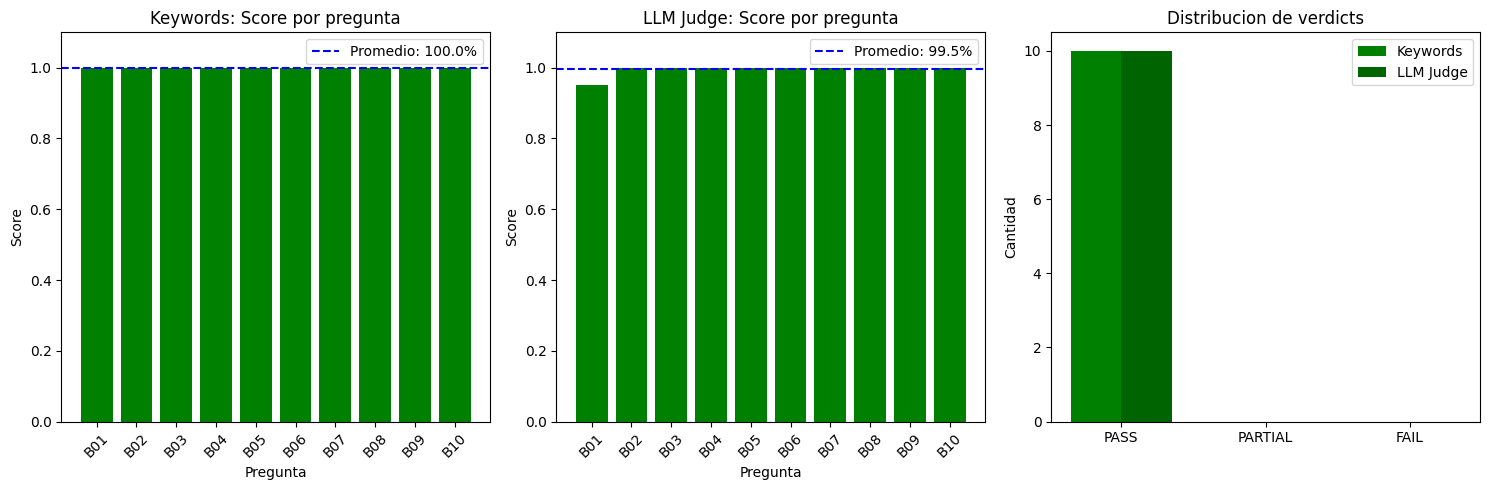


Keywords — Score promedio: 100.0%
LLM Judge — Score promedio: 99.5%


In [69]:
# ══════════════════════════════════════════════════════════════════════
# VISUALIZACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Scores por pregunta — keywords
ids = [r["id"] for r in keyword_results]
kw_scores = [r["score"] for r in keyword_results]
colors_kw = ["green" if s == 1.0 else ("orange" if s > 0 else "red") for s in kw_scores]
axes[0].bar(ids, kw_scores, color=colors_kw)
axes[0].axhline(y=avg_score, color='blue', linestyle='--', label=f'Promedio: {avg_score:.1%}')
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Keywords: Score por pregunta")
axes[0].set_xlabel("Pregunta")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 2. Scores por pregunta — LLM judge
llm_scores = [r["score"] for r in llm_results]
colors_llm = ["green" if s >= 0.8 else ("orange" if s >= 0.4 else "red") for s in llm_scores]
axes[1].bar(ids, llm_scores, color=colors_llm)
axes[1].axhline(y=avg_score_llm, color='blue', linestyle='--', label=f'Promedio: {avg_score_llm:.1%}')
axes[1].set_ylim(0, 1.1)
axes[1].set_title("LLM Judge: Score por pregunta")
axes[1].set_xlabel("Pregunta")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3. Distribucion de verdicts — ambos metodos
verdicts_kw = Counter(r["status"] for r in keyword_results)
verdicts_llm = Counter(r["status"] for r in llm_results)
categories = ["PASS", "PARTIAL", "FAIL"]
x = np.arange(len(categories))
width = 0.35
bars1 = axes[2].bar(x - width/2, [verdicts_kw.get(c, 0) for c in categories], width, label='Keywords', color=['green', 'orange', 'red'])
bars2 = axes[2].bar(x + width/2, [verdicts_llm.get(c, 0) for c in categories], width, label='LLM Judge', color=['darkgreen', 'darkorange', 'darkred'])
axes[2].set_title("Distribucion de verdicts")
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories)
axes[2].set_ylabel("Cantidad")
axes[2].legend()

plt.tight_layout()
plt.show()
print(f"\nKeywords — Score promedio: {avg_score:.1%}")
print(f"LLM Judge — Score promedio: {avg_score_llm:.1%}")

---

## Ejercicio 5: Analizar, refinar, re-evaluar

Mira los resultados del benchmark. Si hay preguntas con FAIL o PARTIAL:

1. **Diagnostica**: mira que tools uso el agente (o si no uso ninguna). El problema esta en las descripciones de las tools, en el system prompt, o en ambos?
2. **Refina**: volve a las celdas del Ejercicio 1 y/o 2 y modifica las descripciones o el prompt
3. **Re-evalua**: volve a correr las celdas del Ejercicio 3 y 4 para ver si mejoro

Podes repetir este ciclo cuantas veces quieras.

> Este loop de **evaluar → analizar → refinar → re-evaluar** es el flujo real
> de trabajo cuando se desarrollan agentes con LLMs.

---

## Ejercicio 6: Preguntas conceptuales

Responde en las celdas de abajo.

### 6.1 — MCP vs function calling directo
Que cambia entre registrar las tools directamente en el agente (Parte 1)
vs descubrirlas via un servidor MCP (Parte 2)? Que ventajas tiene separar
las tools del agente?

En la Parte 1 las tools están hardcodeadas dentro del agente, o sea que si queres agregar o cambiar una tool tenés que tocar el código del agente directamente. En la Parte 2 en cambio, el agente le pregunta al servidor MCP en runtime qué tools tiene disponibles, entonces no sabe de antemano cuáles son.
La ventaja principal de separar las tools en un servidor MCP es que podés modificar, agregar o sacar tools sin tocar el agente para nada. Si en algún momento se quiere agregar una tool nueva, la registras en el servidor y el agente la descubre solo. Eso hace que el sistema sea mucho más fácil de mantener y escalar.

### 6.2 — Tool descriptions
Cual fue la descripcion mas dificil de escribir? El agente elegia mal alguna tool
hasta que mejoraste su descripcion? Que aprendiste sobre como el LLM interpreta las descripciones?

La más difícil fue get_treatment_options. Al principio la descripción era muy generica y el agente a veces la usaba cuando debería haber usado search_drug, especialmente cuando la pregunta mencionaba un medicamento por nombre en vez de un target molecular. Tuve que ser más específico en explicarle cuándo usarla y cuándo no.
Lo que aprendi es que el LLM interpreta las descripciones casi como si fueran instrucciones de trabajo, si la descripción es ambigua, el modelo elige la tool que le parece más parecida aunque no sea la correcta. Cuanto mas claro sos sobre los casos de uso y los casos donde NO usar la tool, mejor elige.

### 6.3 — Keywords vs LLM-as-a-Judge
Hubo discrepancias entre los dos metodos de evaluacion? Cual te parece mas justo y por que?
Que ventajas y desventajas tiene cada uno?

Sí, hubo bastantes discrepancias. El caso mas claro fue B08 donde Keywords me daba FAIL pero el LLM Judge lo marcaba PASS, porque el agente respondia correctamente pero usando palabras un poco diferentes a las esperadas.
El método de Keywords es muy estricto, si la respuesta dice "ALK+" en vez de "ALK" ya falla, aunque el significado sea el mismo. Es facil de implementar y reproducible, pero no entiende el significado real de la respuesta.
El LLM-as-a-Judge me parece más justo porque evalúa si la información clínica importante está presente, no si las palabras son exactas. La desventaja es que puede variar entre corridas y es mas caro computacionalmente.
Para un dominio médico como este yo prefiero el LLM Judge, lo que importa es que el agente dé la información correcta, no que use exactamente las mismas palabras que el benchmark espera.

### 6.4 — Datos clinicos vs datos farmacologicos
Como se complementan el agente de Parte 1 (ensayo clinico ACME) y el de Parte 2 (medicamentos)?
Que tipo de preguntas NO puede responder este agente que si podria el de Parte 1 (y viceversa)?

Los dos agentes se complementan porque cubren cosas distintas. El de Parte 1 conoce todo el contexto del ensayo ACME, como cuantos pacientes hay, las tasas de respuesta, los costos y las tecnologías futuras, pero no sabe nada de farmacología. El de Parte 2 es lo opuesto, maneja mecanismos de acción, dosis, interacciones y contraindicaciones, pero no tiene información sobre ningún ensayo clínico puntual.
El agente de Parte 1 no podria decirte la dosis de osimertinib ni si se puede combinar con warfarina. Y el de Parte 2 no sabría cuantos pacientes tiene la cohorte de ACME ni cuánto invirtieron en I+D. Un sistema más completo tendria los dos integrados para poder responder preguntas que cruzan los dos dominios.